# Intro Progenetix 

### Exercise 4. Download and interpret CNV frequency data

Now download the CNV frequency table for:

Example:
- `Small cell carcinoma, NOS`
- filter code: `pgx:icdom-80413`

Tasks:
- download the frequency table
- inspect its shape
- inspect its columns
- Explain why the frequency table has a different shape from the sample table.
    - what one row represents in the sample table
    - what one row represents in the frequency table
    - why these two tables cannot be merged row by row

### Download the frequency table, inspect shape 

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

In [17]:
freq_table_url = {"scc_NOS": "https://progenetix.org/services/intervalFrequencies/?output=pgxseg&filters=pgx:icdom-80413"}

response = requests.get(freq_table_url['scc_NOS'], timeout=120)
response.raise_for_status()
df_freqscc = pd.read_csv(StringIO(response.text), sep="\t", comment="#")

print('Shape of the data frame:', df_freqscc.shape)

Shape of the data frame: (3106, 6)


### Inspect columns

In [19]:
print('Columns that are present:', df_freqscc.columns)

# first rows to understand structure
display(df_freqscc.head)

Columns that are present: Index(['reference_name', 'start', 'end', 'gain_frequency', 'loss_frequency',
       'no'],
      dtype='object')


<bound method NDFrame.head of                 reference_name     start       end  gain_frequency  \
pgx:icdom-80413              1         0    400000           4.063   
pgx:icdom-80413              1    400000   1400000          13.397   
pgx:icdom-80413              1   1400000   2400000          13.016   
pgx:icdom-80413              1   2400000   3400000          19.492   
pgx:icdom-80413              1   3400000   4400000          17.778   
...                        ...       ...       ...             ...   
pgx:icdom-80413              Y  52400000  53400000           0.000   
pgx:icdom-80413              Y  53400000  54400000           0.000   
pgx:icdom-80413              Y  54400000  55400000           0.000   
pgx:icdom-80413              Y  55400000  56400000           0.000   
pgx:icdom-80413              Y  56400000  57227415           0.000   

                 loss_frequency    no  
pgx:icdom-80413           2.667     1  
pgx:icdom-80413           8.571     2  
pgx:icdom



### Why frequency table has a different shape from the sample table.
* What one row represents in the sample table: 

In the sample table one row represent one sample. 
* What one row represents in the frequency table:

In the frequency table one row represents one CNV event, the same sample can have different CNVs, so one sample can generate multiple lines. 
* Why these two tables cannot be merged row by row:

They have different cardinality, so the sample wouldn't match the CNV as the same sample can have multiple ones. (sample 1 in sample table is in row 1, but in frequency table could be in the first 50 rows, ...).

# Cancer classification 
### Exercise 3 Inspect one informative bin
Choose one bin from the interpretation table.

Tasks:
- write down whether that bin favors glioblastoma or ovarian HGSC
- inspect the histogram for that bin
- open the Progenetix collation plot link and describe whether the broad group-level pattern seems consistent with the model result

In [13]:
# Data used here comes from the full analysis notebook. 
import pandas as pd
import matplotlib.pyplot as plt

model_df = pd.read_csv("data/model_df.csv")
top_positive = pd.read_csv("data/top_positive.csv")
coefs = pd.read_csv("data/coefs.csv", index_col=0).squeeze()

GROUP_1 = "NCIT:C105555"
GROUP_2 = "NCIT:C3058"

GROUP_LABELS = {
    GROUP_1: "Ovarian high-grade serous adenocarcinoma",
    GROUP_2: "Glioblastoma",
}

### Choose one bin 

In [14]:
chosen_bin = top_positive.iloc[0]
bin_id = chosen_bin["bin_id"]

print("Chosen bin:", bin_id)
print("Coefficient:", coefs[bin_id])
print("This bin favors Glioblastoma")

Chosen bin: chr7_20000000_30000000
Coefficient: 0.3076868857014864
This bin favors Glioblastoma


### Show histogram

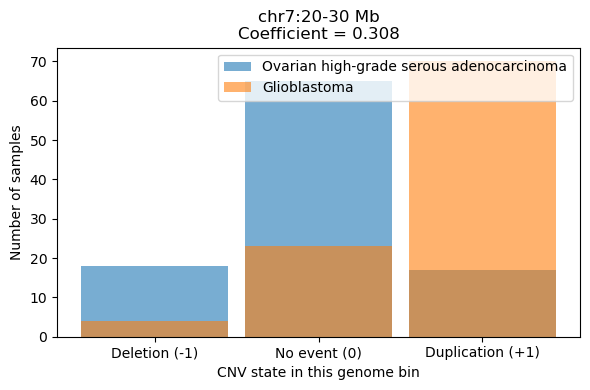

In [15]:
plot_df = model_df.copy()
plot_df["group_label"] = plot_df["group_code"].map(GROUP_LABELS)

bins_to_plot = (
    top_positive["bin_id"].head(1).tolist())

def format_bin_label(bin_id):
    # Example input: chr13_20000000_30000000
    chrom, start, end = bin_id.replace("chr", "").split("_")
    start_mb = int(start) / 1_000_000
    end_mb = int(end) / 1_000_000
    return f"chr{chrom}:{start_mb:.0f}-{end_mb:.0f} Mb"

plt.figure(figsize=(6, 4))


for group_code in [GROUP_1, GROUP_2]:
    values = plot_df.loc[plot_df["group_code"] == group_code, bin_id]
    plt.hist(
        values,
        bins=[-1.5, -0.5, 0.5, 1.5],
        alpha=0.6,
        label=GROUP_LABELS[group_code],
        rwidth=0.9,
    )

coef_value = coefs[bin_id]
plt.xticks([-1, 0, 1], ["Deletion (-1)", "No event (0)", "Duplication (+1)"])
plt.xlabel("CNV state in this genome bin")
plt.ylabel("Number of samples")
plt.title(f"{format_bin_label(bin_id)}\nCoefficient = {coef_value:.3f}")
plt.legend()
plt.tight_layout()
plt.show()


From the histogram it is noticable that the number of duplications in the Glioblastoma is much higer compared to the Ovarian high-grade serous adenocarcinoma, which shows higher number of no event or deletions. 

### Collation plot

In [16]:
# Progenetix link for the glioblastoma
print("Official Progenetix group-level CNV frequency plot for glioblastoma:","https://progenetix.org/services/collationplots/?filters=NCIT:C3058" )


Official Progenetix group-level CNV frequency plot for glioblastoma: https://progenetix.org/services/collationplots/?filters=NCIT:C3058



From the collation plot on Progenetix we can clearly see that chromosome 7 is subejct to duplications, so the results from the model seem consistent. 